<a href="https://colab.research.google.com/github/Schachkatzen29/GeoSocial_backup_code/blob/main/combinedHeatMobility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gcsfs linearmodels --quiet
from google.colab import auth; auth.authenticate_user()

import gcsfs, pandas as pd, numpy as np
from linearmodels.panel import PanelOLS
import matplotlib.pyplot as plt

fs = gcsfs.GCSFileSystem()
with fs.open("heat-mobility-rq1/mobility/metrics/mobility_metrics_panel_2019.csv") as f:
    mob = pd.read_csv(f, dtype={"GEOID":str}, parse_dates=["date"])
with fs.open("heat-mobility-rq1/processed/maricopa_dailymax_2019_CLEAN.csv") as f:
    heat = pd.read_csv(f, dtype={"GEOID":str}, parse_dates=["local_date"]).rename(columns={"local_date":"date"})

df = mob.merge(heat[["GEOID","date","HI_F","WBGT_clean_F","UTCI_F","airtemp_F"]],
               on=["GEOID","date"], how="inner")
print(f"JOINED: {df.shape} | tracts: {df.GEOID.nunique()} | days: {df.date.nunique()}")

df["dow"] = df["date"].dt.dayofweek

# z-score each index -> betas comparable across indices (THE key step for RQ1)
INDICES = {"HI":"HI_F", "WBGT":"WBGT_clean_F", "UTCI":"UTCI_F"}
for n, c in INDICES.items():
    df[f"z_{n}"] = (df[c] - df[c].mean()) / df[c].std()

# log the skewed volume/distance metrics; keep bounded ones as levels
LOG_M   = ["outflow","OWRg","out_degree","within_flow","gross_flow","inflow","Rg",
           "in_degree","total_degree"]
LEVEL_M = ["out_entropy","in_entropy","total_entropy","WCC","out_gini","in_gini",
           "total_gini","netflow_ratio"]
for m in LOG_M:   df[f"y_{m}"] = np.log(df[m].replace(0, np.nan))
for m in LEVEL_M: df[f"y_{m}"] = df[m]
OUTCOMES = LOG_M + LEVEL_M
print("ready")

JOINED: (136891, 24) | tracts: 895 | days: 153
ready


In [ ]:
def fe(outcome, idx):
    d = df[[f"y_{outcome}", f"z_{idx}", "GEOID", "date", "dow"]].dropna()
    d = d.rename(columns={f"y_{outcome}":"y", f"z_{idx}":"z"}).set_index(["GEOID","date"])
    res = PanelOLS.from_formula("y ~ z + C(dow) + EntityEffects", data=d)\
                  .fit(cov_type="clustered", cluster_entity=True)
    return {"beta":res.params["z"], "se":res.std_errors["z"],
            "p":res.pvalues["z"], "N":int(res.nobs)}

rows = []
for o in OUTCOMES:
    for n in INDICES:
        try:
            r = fe(o, n); r.update({"outcome":o, "index":n}); rows.append(r)
            print(f"{o:15} ~ {n:5}: β={r['beta']:+.4f}  p={r['p']:.2g}  N={r['N']:,}", flush=True)
        except Exception as e:
            print(f"{o:15} ~ {n:5}: FAILED {e}")
R = pd.DataFrame(rows)

outflow         ~ HI   : β=+0.0060  p=1.2e-14  N=136,056
outflow         ~ WBGT : β=+0.0061  p=5.1e-14  N=135,042
outflow         ~ UTCI : β=+0.0049  p=2.3e-11  N=136,056
OWRg            ~ HI   : β=+0.0153  p=8.5e-09  N=136,049
OWRg            ~ WBGT : β=+0.0060  p=0.023  N=135,035
OWRg            ~ UTCI : β=+0.0210  p=1.1e-15  N=136,049
out_degree      ~ HI   : β=-0.0162  p=0  N=136,369
out_degree      ~ WBGT : β=-0.0144  p=0  N=135,353
out_degree      ~ UTCI : β=-0.0135  p=0  N=136,369
within_flow     ~ HI   : β=+0.0023  p=1.4e-06  N=136,165
within_flow     ~ WBGT : β=+0.0053  p=0  N=135,151
within_flow     ~ UTCI : β=+0.0008  p=0.067  N=136,165
gross_flow      ~ HI   : β=-0.0001  p=0.89  N=136,891
gross_flow      ~ WBGT : β=+0.0025  p=0.0021  N=135,873
gross_flow      ~ UTCI : β=-0.0017  p=0.026  N=136,891
inflow          ~ HI   : β=-0.0108  p=0  N=136,891
inflow          ~ WBGT : β=-0.0051  p=3.4e-05  N=135,873
inflow          ~ UTCI : β=-0.0133  p=0  N=136,891
Rg              ~ HI

In [ ]:
wide = R.pivot(index="outcome", columns="index", values="beta")
wide["winner"] = wide[["HI","WBGT","UTCI"]].abs().idxmax(axis=1)
print("="*72); print("RQ1: WHICH INDEX BEST PREDICTS MOBILITY REDUCTION?"); print("="*72)
print(wide.round(4).to_string())
print("\nWINNER TALLY:"); print(wide["winner"].value_counts().to_string())

# are the differences real, or inside the noise?
print("\n=== Is the winner meaningfully ahead? (CI overlap check) ===")
for o in OUTCOMES:
    s = R[R.outcome == o]
    if s.empty: continue
    b = s.set_index("index")
    top = b["beta"].abs().idxmax()
    others = [i for i in ["HI","WBGT","UTCI"] if i != top]
    sep = all(abs(b.loc[top,"beta"]) - 1.96*b.loc[top,"se"] >
              abs(b.loc[x,"beta"]) + 1.96*b.loc[x,"se"] for x in others)
    print(f"  {o:15}: {top:5} {'CLEARLY ahead' if sep else 'within noise of the others'}")

RQ1: WHICH INDEX BEST PREDICTS MOBILITY REDUCTION?
index              HI    UTCI    WBGT winner
outcome                                     
OWRg           0.0153  0.0210  0.0060   UTCI
Rg             0.0157  0.0214  0.0063   UTCI
WCC           -0.0033 -0.0035 -0.0013   UTCI
gross_flow    -0.0001 -0.0017  0.0025   WBGT
in_degree     -0.0307 -0.0300 -0.0220     HI
in_entropy    -0.0024 -0.0022 -0.0020     HI
in_gini       -0.0034 -0.0040 -0.0001   UTCI
inflow        -0.0108 -0.0133 -0.0051   UTCI
netflow_ratio -0.0067 -0.0073 -0.0042   UTCI
out_degree    -0.0162 -0.0135 -0.0144     HI
out_entropy   -0.0022 -0.0019 -0.0017     HI
out_gini      -0.0050 -0.0058 -0.0015   UTCI
outflow        0.0060  0.0049  0.0061   WBGT
total_degree  -0.0172 -0.0152 -0.0142     HI
total_entropy -0.0012 -0.0010 -0.0011     HI
total_gini    -0.0044 -0.0051 -0.0011   UTCI
within_flow    0.0023  0.0008  0.0053   WBGT

WINNER TALLY:
winner
UTCI    8
HI      6
WBGT    3

=== Is the winner meaningfully ahead? (CI

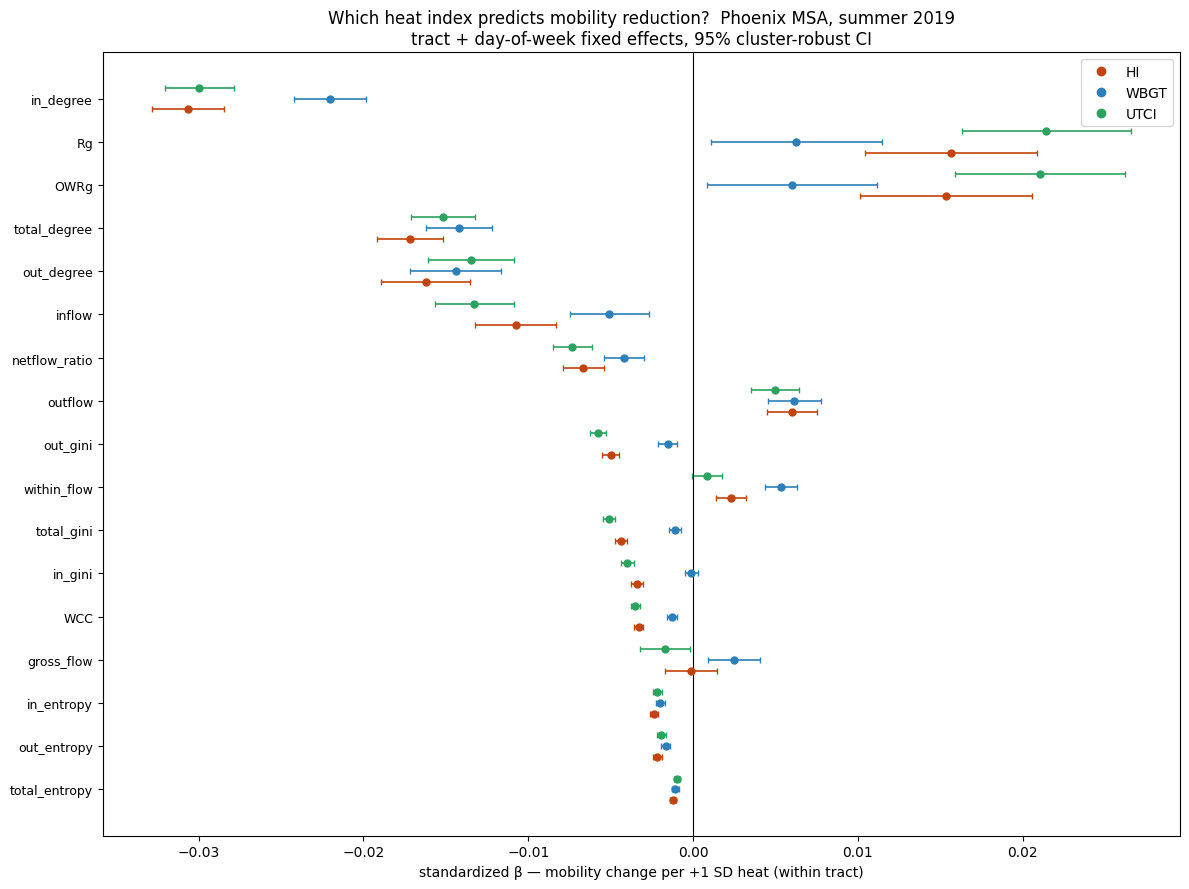

In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))
order = R.groupby("outcome")["beta"].apply(lambda s: s.abs().max()).sort_values().index
ypos = {o:i for i,o in enumerate(order)}
C = {"HI":"#c1440e","WBGT":"#2c7fb8","UTCI":"#2ca25f"}
off = {"HI":-0.25,"WBGT":0.0,"UTCI":0.25}
for _, r in R.iterrows():
    ax.errorbar(r.beta, ypos[r.outcome]+off[r["index"]], xerr=1.96*r.se, fmt="o",
                color=C[r["index"]], ms=5, capsize=2, lw=1.2)
ax.axvline(0, color="k", lw=0.8)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=9)
ax.set_xlabel("standardized β — mobility change per +1 SD heat (within tract)")
ax.set_title("Which heat index predicts mobility reduction?  Phoenix MSA, summer 2019\n"
             "tract + day-of-week fixed effects, 95% cluster-robust CI", fontsize=12)
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([0],[0],marker="o",color=c,label=n,lw=0) for n,c in C.items()])
plt.tight_layout(); plt.savefig("jobB_answer.png", dpi=220, bbox_inches="tight"); plt.show()
R.to_csv("jobB_results.csv", index=False)

In [ ]:
# what IS one SD of heat?
for n, c in INDICES.items():
    print(f"1 SD of {n} = {df[c].std():.2f} °F")

# betas in per-10°F, percent terms
out = []
for _, r in R.iterrows():
    sd_f = df[INDICES[r["index"]]].std()
    per10 = r.beta * (10 / sd_f)                    # rescale SD -> 10°F
    out.append({"outcome": r.outcome, "index": r["index"],
                "pct_per_10F": per10*100 if r.outcome in LOG_M else np.nan,
                "pts_per_10F": per10 if r.outcome in LEVEL_M else np.nan})
print(pd.DataFrame(out).pivot(index="outcome", columns="index").round(2).to_string())

1 SD of HI = 9.36 °F
1 SD of WBGT = 7.19 °F
1 SD of UTCI = 11.11 °F
              pct_per_10F             pts_per_10F            
index                  HI  UTCI  WBGT          HI  UTCI  WBGT
outcome                                                      
OWRg                 1.64  1.89  0.83         NaN   NaN   NaN
Rg                   1.67  1.93  0.87         NaN   NaN   NaN
WCC                   NaN   NaN   NaN       -0.00 -0.00 -0.00
gross_flow          -0.01 -0.15  0.34         NaN   NaN   NaN
in_degree           -3.28 -2.70 -3.06         NaN   NaN   NaN
in_entropy            NaN   NaN   NaN       -0.00 -0.00 -0.00
in_gini               NaN   NaN   NaN       -0.00 -0.00 -0.00
inflow              -1.15 -1.20 -0.71         NaN   NaN   NaN
netflow_ratio         NaN   NaN   NaN       -0.01 -0.01 -0.01
out_degree          -1.73 -1.21 -2.01         NaN   NaN   NaN
out_entropy           NaN   NaN   NaN       -0.00 -0.00 -0.00
out_gini              NaN   NaN   NaN       -0.01 -0.01 -0.00
ou

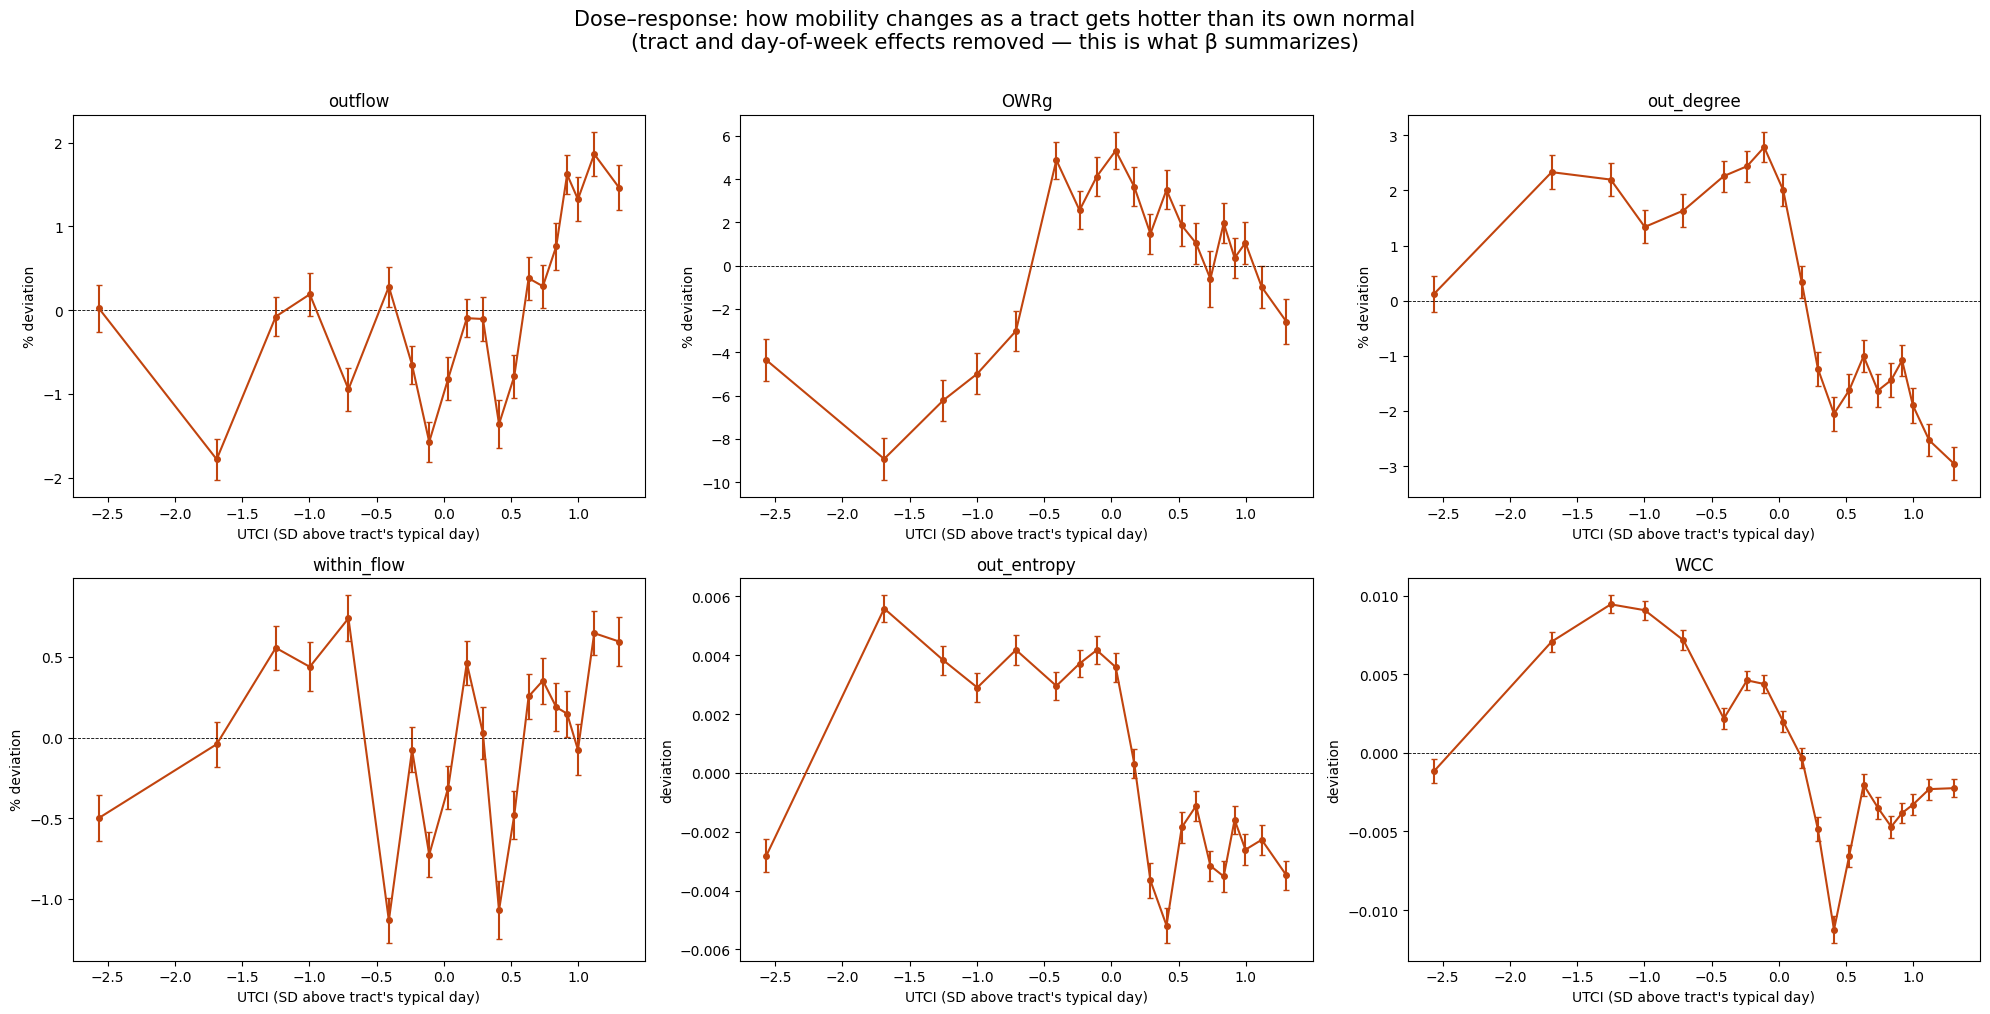

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
SHOW = ["outflow","OWRg","out_degree","within_flow","out_entropy","WCC"]

for ax, m in zip(axes.flat, SHOW):
    d = df[[f"y_{m}", "z_UTCI", "GEOID", "dow"]].dropna().copy()
    # remove tract + day-of-week effects, exactly as the model does
    d["resid"] = (d[f"y_{m}"]
                  - d.groupby("GEOID")[f"y_{m}"].transform("mean")
                  - d.groupby("dow")[f"y_{m}"].transform("mean")
                  + d[f"y_{m}"].mean())
    d["bin"] = pd.qcut(d["z_UTCI"], 20, labels=False, duplicates="drop")
    b = d.groupby("bin").agg(heat=("z_UTCI","mean"), y=("resid","mean"),
                             se=("resid", lambda s: s.std()/np.sqrt(len(s))))
    ax.errorbar(b.heat, b.y*100 if m in LOG_M else b.y, yerr=b.se*196 if m in LOG_M else b.se*1.96,
                fmt="o-", color="#c1440e", ms=4, capsize=2)
    ax.axhline(0, color="k", lw=0.6, ls="--")
    ax.set_title(m, fontsize=12)
    ax.set_xlabel("UTCI (SD above tract's typical day)")
    ax.set_ylabel("% deviation" if m in LOG_M else "deviation")
fig.suptitle("Dose–response: how mobility changes as a tract gets hotter than its own normal\n"
             "(tract and day-of-week effects removed — this is what β summarizes)",
             fontsize=15, y=1.01)
plt.tight_layout(); plt.savefig("dose_response.png", dpi=220, bbox_inches="tight"); plt.show()

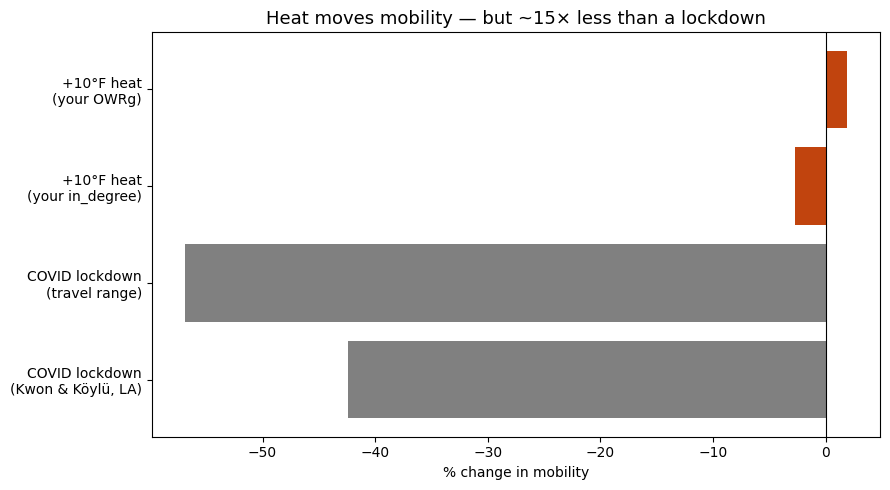

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))
comp = pd.DataFrame({
    "effect": ["COVID lockdown\n(Kwon & Köylü, LA)", "COVID lockdown\n(travel range)",
               "+10°F heat\n(your in_degree)", "+10°F heat\n(your OWRg)"],
    "pct":    [-42.4, -56.9,
               R.query("outcome=='in_degree' & index=='UTCI'").beta.iloc[0]*(10/df["UTCI_F"].std())*100,
               R.query("outcome=='OWRg' & index=='UTCI'").beta.iloc[0]*(10/df["UTCI_F"].std())*100]})
ax.barh(comp.effect, comp.pct, color=["grey","grey","#c1440e","#c1440e"])
ax.axvline(0, color="k", lw=0.8); ax.set_xlabel("% change in mobility")
ax.set_title("Heat moves mobility — but ~15× less than a lockdown", fontsize=13)
plt.tight_layout(); plt.savefig("effect_size_context.png", dpi=220, bbox_inches="tight"); plt.show()

In [ ]:
del C

# target the real problem, not the 5th percentile
dff = df[(df.gross_flow >= 100) & (df.outflow > 0)].copy()
print(f"filter: gross_flow>=100 AND outflow>0 -> {len(dff):,} of {len(df):,} "
      f"({100*(1-len(dff)/len(df)):.1f}% dropped)")

for o in ["netflow_ratio","out_entropy","OWRg","in_degree","total_gini"]:
    for n in ["HI","WBGT","UTCI"]:
        d = dff[[f"y_{o}", f"z_{n}", "GEOID","date","dow"]].dropna()
        d = d.rename(columns={f"y_{o}":"y", f"z_{n}":"z"}).set_index(["GEOID","date"])
        r = PanelOLS.from_formula("y ~ z + C(dow) + EntityEffects", data=d)\
                    .fit(cov_type="clustered", cluster_entity=True)
        base = R.query("outcome==@o & index==@n").beta.iloc[0]
        drift = abs(r.params["z"] - base)
        flag = "  <-- MOVED" if drift > abs(base)*0.2 else ""
        print(f"{o:14} ~ {n:5}: filtered β={r.params['z']:+.4f}  (was {base:+.4f}){flag}")

filter: gross_flow>=100 AND outflow>0 -> 136,054 of 136,891 (0.6% dropped)
netflow_ratio  ~ HI   : filtered β=-0.0067  (was -0.0067)
netflow_ratio  ~ WBGT : filtered β=-0.0042  (was -0.0042)
netflow_ratio  ~ UTCI : filtered β=-0.0074  (was -0.0073)
out_entropy    ~ HI   : filtered β=-0.0022  (was -0.0022)
out_entropy    ~ WBGT : filtered β=-0.0017  (was -0.0017)
out_entropy    ~ UTCI : filtered β=-0.0019  (was -0.0019)
OWRg           ~ HI   : filtered β=+0.0154  (was +0.0153)
OWRg           ~ WBGT : filtered β=+0.0060  (was +0.0060)
OWRg           ~ UTCI : filtered β=+0.0211  (was +0.0210)
in_degree      ~ HI   : filtered β=-0.0303  (was -0.0307)
in_degree      ~ WBGT : filtered β=-0.0216  (was -0.0220)
in_degree      ~ UTCI : filtered β=-0.0296  (was -0.0300)
total_gini     ~ HI   : filtered β=-0.0044  (was -0.0044)
total_gini     ~ WBGT : filtered β=-0.0011  (was -0.0011)
total_gini     ~ UTCI : filtered β=-0.0051  (was -0.0051)


In [ ]:
print("Rg vs OWRg correlation:", df["Rg"].corr(df["OWRg"], method="spearman").round(4))
print("OWRg >= Rg in what fraction of tract-days?", (df["OWRg"] >= df["Rg"]).mean().round(4))
print((df["OWRg"] / df["Rg"]).describe().round(3).to_string())

Rg vs OWRg correlation: 0.9998
OWRg >= Rg in what fraction of tract-days? 0.9811
count    136049.000
mean            inf
std             NaN
min           0.997
25%           1.002
50%           1.004
75%           1.007
max             inf


In [ ]:
!pip install pygris --quiet
from pygris import tracts
import numpy as np

az = tracts(state="04", county="013", year=2019, cache=True)
az["GEOID"] = az["GEOID"].astype(str)

VOLUME    = ["gross_flow","inflow","outflow","netflow","netflow_ratio","within_flow"]
DISTANCE  = ["Rg","OWRg"]
TOPOLOGY  = ["total_degree","in_degree","out_degree"]
STRUCTURE = ["WCC","total_entropy","in_entropy","out_entropy","total_gini","in_gini","out_gini"]
ALL18 = VOLUME + DISTANCE + TOPOLOGY + STRUCTURE

mp = df   # the variance decomposition uses the joined frame; either works
print("ready")

ready


In [ ]:
# find out where your top hub actually is
top = hubs.index[0]
pt = az[az.GEOID == top].to_crs(4326).geometry.centroid.iloc[0]
print(f"tract {top}: {pt.y:.5f}, {pt.x:.5f}")
print(f"https://www.google.com/maps/@{pt.y:.5f},{pt.x:.5f},15z")

tract 04013113802: 33.43292, -112.00270
https://www.google.com/maps/@33.43292,-112.00270,15z


/tmp/ipykernel_613/2362597433.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pt = az[az.GEOID == top].to_crs(4326).geometry.centroid.iloc[0]


In [ ]:
# your within-standardized matrix (from earlier)
mu = mp.groupby("GEOID")[ALL18].transform("mean")
sd = mp.groupby("GEOID")[ALL18].transform("std").replace(0, np.nan)
D = ((mp[ALL18]-mu)/sd).replace([np.inf,-np.inf], np.nan).corr("spearman")

PAPER = {  # (metric_a, metric_b): (LA, NY)
    ("Rg","OWRg"): (0.97, 0.97),
    ("netflow","netflow_ratio"): (0.99, 1.00),
    ("gross_flow","inflow"): (0.70, 0.76),
    ("gross_flow","outflow"): (0.74, 0.71),
    ("inflow","outflow"): (0.25, 0.30),
    ("WCC","gross_flow"): (-0.32, -0.36),
    ("WCC","inflow"): (-0.32, -0.36),
    ("WCC","total_degree"): (-0.37, -0.39),
    ("WCC","within_flow"): (0.05, 0.08),
    ("in_gini","in_entropy"): (-0.71, -0.68),
    ("total_degree","in_degree"): (0.73, 0.72),
    ("total_degree","out_degree"): (0.82, 0.84),
}
print(f"{'pair':32} {'yours':>8} {'LA':>7} {'NY':>7}   sign?")
print("-"*70)
for (a,b),(la,ny) in PAPER.items():
    y = D.loc[a,b]
    ok = "MATCH" if np.sign(y)==np.sign(la) else "*** FLIPPED ***"
    print(f"{a+' ~ '+b:32} {y:+8.3f} {la:+7.2f} {ny:+7.2f}   {ok}")

# block structure: is within-category > cross-category?
CAT = {**{m:"volume" for m in VOLUME}, **{m:"distance" for m in DISTANCE},
       **{m:"topology" for m in TOPOLOGY}, **{m:"structure" for m in STRUCTURE}}
tri = np.triu(np.ones(D.shape), k=1).astype(bool)
pairs = D.where(tri).stack().reset_index()
pairs.columns = ["a","b","rho"]
pairs["same_cat"] = pairs.a.map(CAT) == pairs.b.map(CAT)
print("\n=== Does the block structure hold? (the paper's headline) ===")
print(pairs.groupby("same_cat")["rho"].agg(["count","mean","median"]).round(3).to_string())
print("\nmean |rho| within-category :", pairs[pairs.same_cat].rho.abs().mean().round(3))
print("mean |rho| cross-category  :", pairs[~pairs.same_cat].rho.abs().mean().round(3))

pair                                yours      LA      NY   sign?
----------------------------------------------------------------------
Rg ~ OWRg                          +1.000   +0.97   +0.97   MATCH
netflow ~ netflow_ratio            +0.895   +0.99   +1.00   MATCH
gross_flow ~ inflow                +0.784   +0.70   +0.76   MATCH
gross_flow ~ outflow               +0.697   +0.74   +0.71   MATCH
inflow ~ outflow                   +0.250   +0.25   +0.30   MATCH
WCC ~ gross_flow                   +0.242   -0.32   -0.36   *** FLIPPED ***
WCC ~ inflow                       +0.094   -0.32   -0.36   *** FLIPPED ***
WCC ~ total_degree                 +0.176   -0.37   -0.39   *** FLIPPED ***
WCC ~ within_flow                  +0.204   +0.05   +0.08   MATCH
in_gini ~ in_entropy               -0.227   -0.71   -0.68   MATCH
total_degree ~ in_degree           +0.723   +0.73   +0.72   MATCH
total_degree ~ out_degree          +0.782   +0.82   +0.84   MATCH

=== Does the block structure hold? (the 

In [ ]:
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

plt.rcParams.update({"font.family":"DejaVu Sans", "figure.dpi":110})
CATS = [("Volume", VOLUME, "#c1440e"), ("Distance", DISTANCE, "#2c7fb8"),
        ("Topology", TOPOLOGY, "#2ca25f"), ("Structure", STRUCTURE, "#756bb1")]

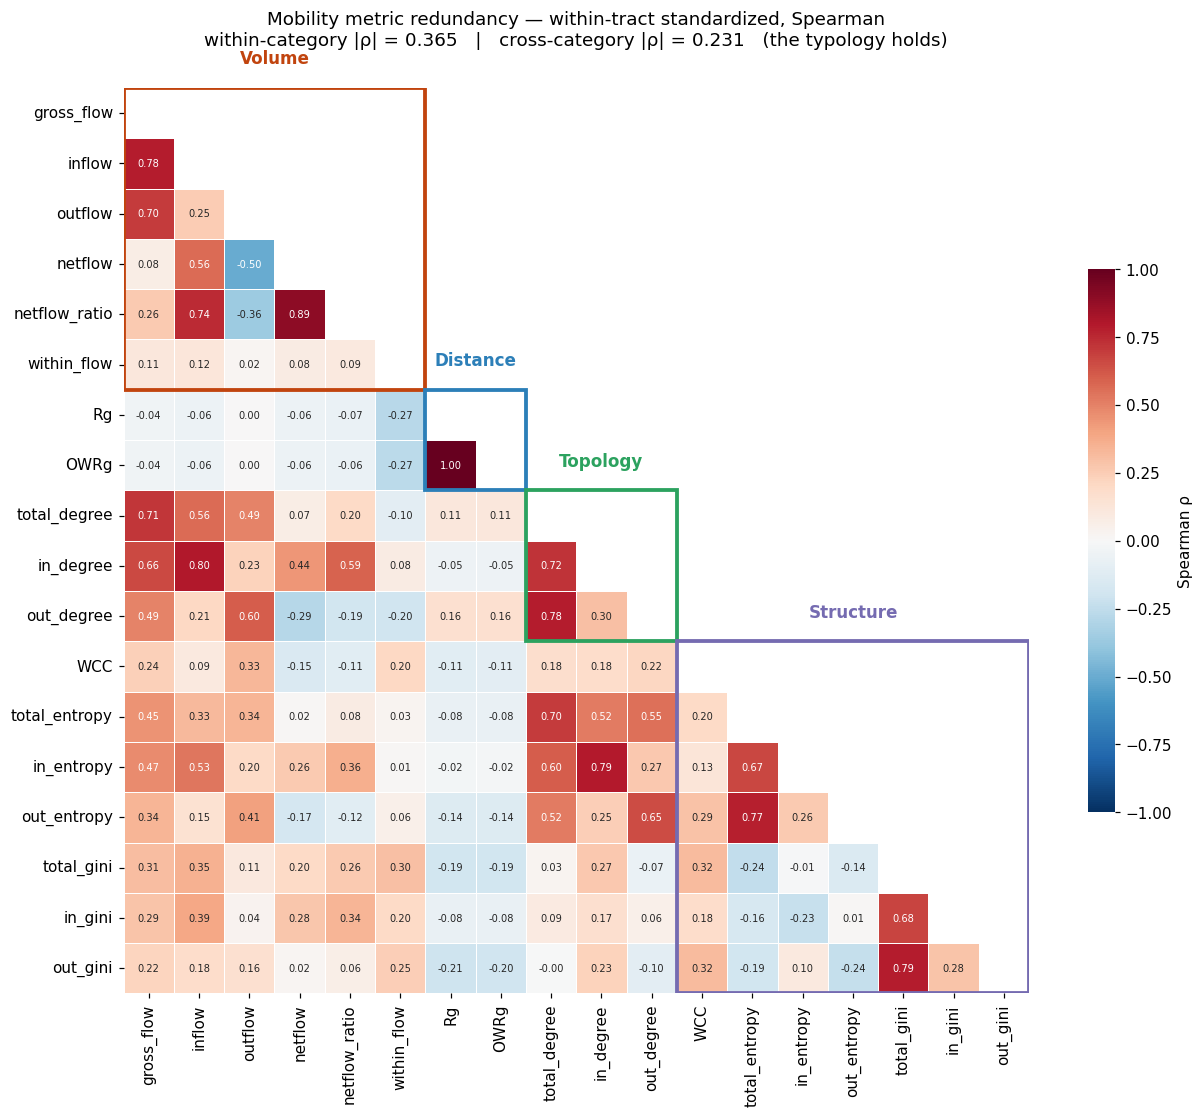

In [ ]:
mask = np.triu(np.ones_like(D, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(D, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, linewidths=0.5, linecolor="white",
            annot_kws={"size":6.5}, cbar_kws={"label":"Spearman ρ", "shrink":0.6}, ax=ax)

# block boxes + category labels
start = 0
for name, cols, color in CATS:
    n = len(cols)
    ax.add_patch(Rectangle((start, start), n, n, fill=False, edgecolor=color, lw=2.5, zorder=5))
    ax.text(start + n/2, start - 0.4, name, ha="center", va="bottom",
            fontsize=11, weight="bold", color=color)
    start += n

ax.set_title("Mobility metric redundancy — within-tract standardized, Spearman\n"
             f"within-category |ρ| = 0.365   |   cross-category |ρ| = 0.231   "
             "(the typology holds)", fontsize=12, pad=28)
plt.tight_layout(); plt.savefig("fig_matrix.png", dpi=250, bbox_inches="tight"); plt.show()

/tmp/ipykernel_613/4215621447.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pt = gh[gh.GEOID == top].geometry.centroid.iloc[0]


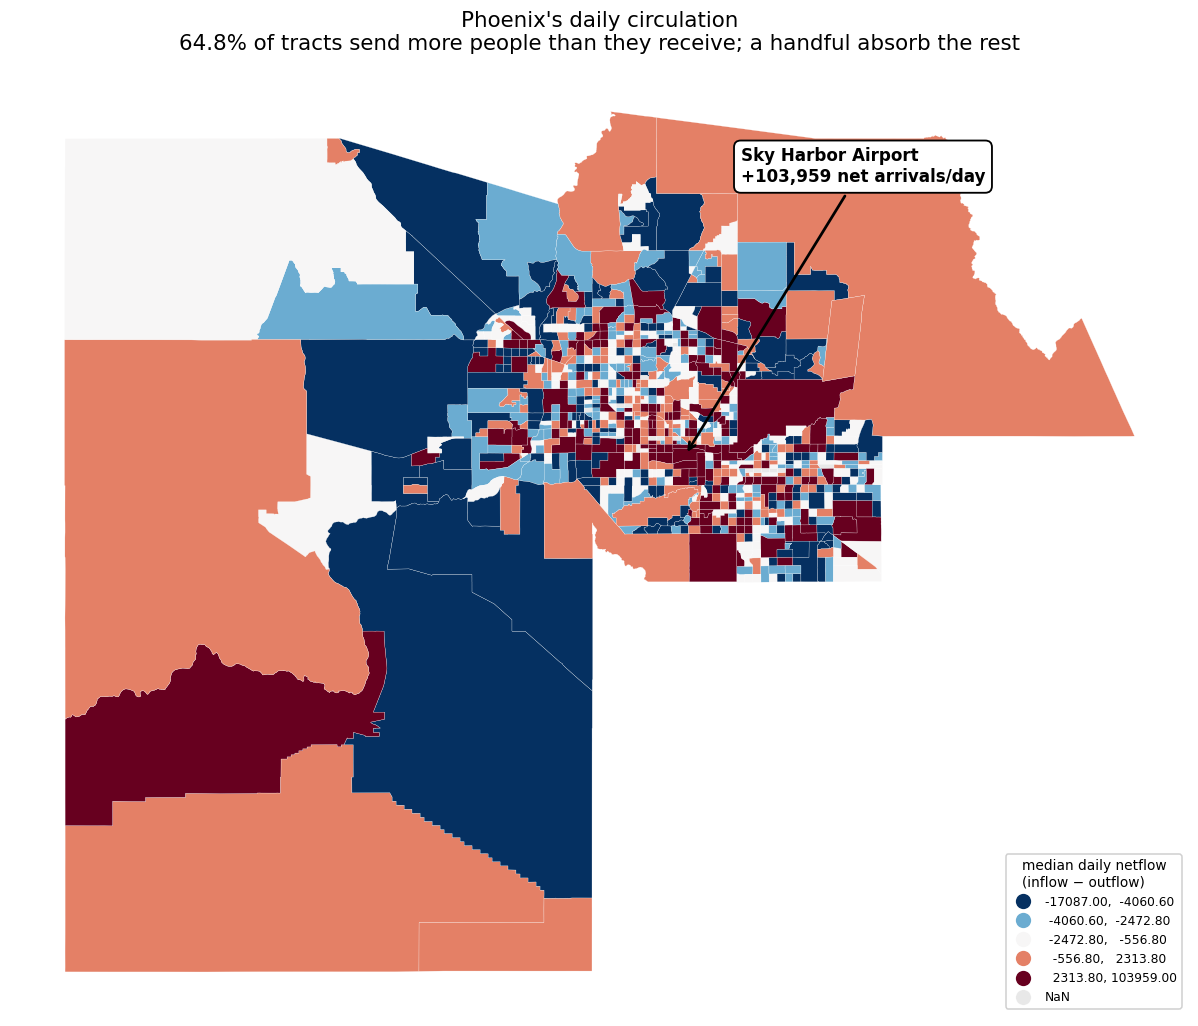

In [ ]:
hubs = df.groupby("GEOID")["netflow"].median()
gh = az.merge(hubs.rename("nf").reset_index(), on="GEOID", how="left")
top = hubs.idxmax()
pt = gh[gh.GEOID == top].geometry.centroid.iloc[0]

fig, ax = plt.subplots(figsize=(11, 11))
gh.plot(column="nf", ax=ax, cmap="RdBu_r", scheme="quantiles", k=5,
        edgecolor="white", linewidth=0.15, legend=True,
        legend_kwds={"title":"median daily netflow\n(inflow − outflow)",
                     "loc":"lower right", "fontsize":8, "title_fontsize":9,
                     "frameon":True, "framealpha":0.92},
        missing_kwds={"color":"#e8e8e8"})

# lock the extent BEFORE annotating so nothing can expand the canvas
ax.set_xlim(*ax.get_xlim()); ax.set_ylim(*ax.get_ylim())

ax.annotate(f"Sky Harbor Airport\n+{hubs.max():,.0f} net arrivals/day",
            xy=(pt.x, pt.y), xycoords="data",
            xytext=(0.62, 0.88), textcoords="axes fraction",   # <-- CRS-independent
            fontsize=11, weight="bold", ha="left",
            arrowprops=dict(arrowstyle="->", lw=1.8, color="black"),
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1.2))

ax.set_title("Phoenix's daily circulation\n"
             "64.8% of tracts send more people than they receive; "
             "a handful absorb the rest", fontsize=14, pad=12)
ax.axis("off")
plt.tight_layout(); plt.savefig("fig_netflow.png", dpi=250, bbox_inches="tight"); plt.show()

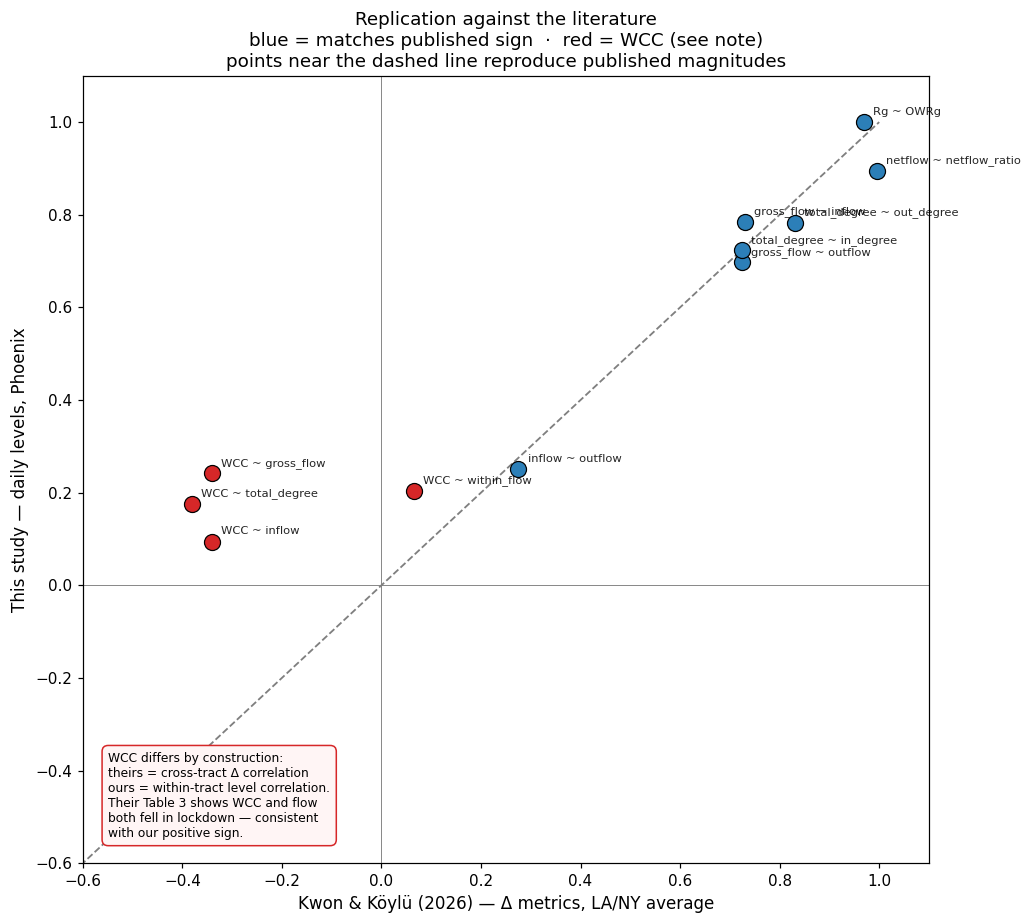

In [ ]:
rows = [(f"{a} ~ {b}", D.loc[a,b], la, ny) for (a,b),(la,ny) in PAPER.items()]
C = pd.DataFrame(rows, columns=["pair","yours","LA","NY"])
C["paper"] = C[["LA","NY"]].mean(axis=1)
C["is_wcc"] = C.pair.str.contains("WCC")

fig, ax = plt.subplots(figsize=(9.5, 8.5))
ax.plot([-1,1], [-1,1], "k--", lw=1.2, alpha=0.5, zorder=1)
ax.axhline(0, color="grey", lw=0.6); ax.axvline(0, color="grey", lw=0.6)

for _, r in C.iterrows():
    col = "#d62728" if r.is_wcc else "#2c7fb8"
    ax.scatter(r.paper, r.yours, s=110, color=col, edgecolor="k", lw=0.8, zorder=3)
    ax.annotate(r.pair, (r.paper, r.yours), xytext=(6, 5), textcoords="offset points",
                fontsize=7.5, alpha=0.85)

ax.set_xlabel("Kwon & Köylü (2026) — Δ metrics, LA/NY average", fontsize=11)
ax.set_ylabel("This study — daily levels, Phoenix", fontsize=11)
ax.set_title("Replication against the literature\n"
             "blue = matches published sign  ·  red = WCC (see note)\n"
             "points near the dashed line reproduce published magnitudes",
             fontsize=12)
ax.text(0.03, 0.03,
        "WCC differs by construction:\ntheirs = cross-tract Δ correlation\n"
        "ours = within-tract level correlation.\nTheir Table 3 shows WCC and flow\n"
        "both fell in lockdown — consistent\nwith our positive sign.",
        transform=ax.transAxes, fontsize=8, va="bottom",
        bbox=dict(boxstyle="round,pad=0.5", fc="#fff5f5", ec="#d62728", lw=1))
ax.set_xlim(-0.6, 1.1); ax.set_ylim(-0.6, 1.1)
plt.tight_layout(); plt.savefig("fig_replication.png", dpi=250, bbox_inches="tight"); plt.show()

/tmp/ipykernel_613/297655591.py:11: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  pt = gh[gh.GEOID == top].geometry.centroid.iloc[0]


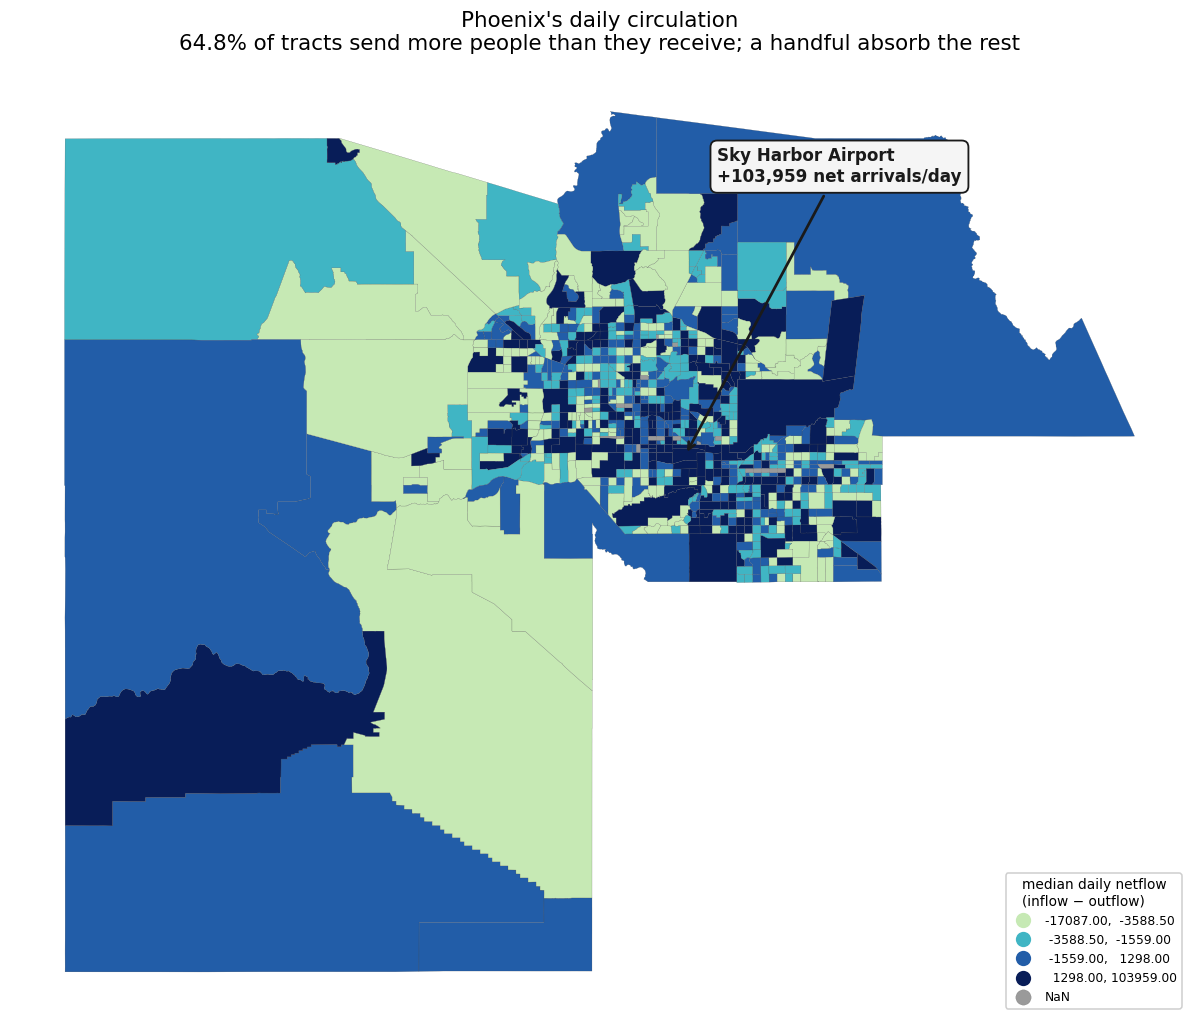

quantile breaks: [-17087.  -3588.  -1559.   1298. 103959.]
zero sits at the 63.3th percentile — between class 3 and 4


In [ ]:
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# ColorBrewer sequential, 5-class, drop the palest -> darkest 4
def dark4(name):
    return ListedColormap([plt.get_cmap(name)(i) for i in np.linspace(0, 1, 5)][1:])

hubs = df.groupby("GEOID")["netflow"].median()
gh = az.merge(hubs.rename("nf").reset_index(), on="GEOID", how="left")
top = hubs.idxmax()
pt = gh[gh.GEOID == top].geometry.centroid.iloc[0]

fig, ax = plt.subplots(figsize=(11, 11))
gh.plot(column="nf", ax=ax, cmap=dark4("YlGnBu"), scheme="quantiles", k=4,
        edgecolor="#4a4a4a", linewidth=0.12,          # dark grey borders, not white
        legend=True,
        legend_kwds={"title":"median daily netflow\n(inflow − outflow)",
                     "loc":"lower right", "fontsize":8, "title_fontsize":9,
                     "frameon":True, "framealpha":0.95},
        missing_kwds={"color":"#9a9a9a"})             # darker no-data

ax.set_xlim(*ax.get_xlim()); ax.set_ylim(*ax.get_ylim())

ax.annotate(f"Sky Harbor Airport\n+{hubs.max():,.0f} net arrivals/day",
            xy=(pt.x, pt.y), xycoords="data",
            xytext=(0.60, 0.88), textcoords="axes fraction",
            fontsize=11, weight="bold", ha="left", color="#1a1a1a",
            arrowprops=dict(arrowstyle="->", lw=1.8, color="#1a1a1a"),
            bbox=dict(boxstyle="round,pad=0.4", fc="#f5f5f5", ec="#1a1a1a", lw=1.2))

ax.set_title("Phoenix's daily circulation\n"
             "64.8% of tracts send more people than they receive; "
             "a handful absorb the rest", fontsize=14, pad=12)
ax.axis("off")
plt.tight_layout(); plt.savefig("fig_netflow.png", dpi=250, bbox_inches="tight"); plt.show()

# where does zero actually fall in the legend?
brk = np.quantile(gh["nf"].dropna(), [0, .25, .5, .75, 1])
print("quantile breaks:", brk.round(0))
print(f"zero sits at the {100*(gh['nf'] < 0).mean():.1f}th percentile — "
      f"between class {np.searchsorted(brk, 0)} and {np.searchsorted(brk, 0)+1}")